# BPR Collaborative Filtering with Matrix Factorization

This notebook trains a small implicit-feedback matrix factorization model on `ratings.csv` with BPR and uses it to recommend movies.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ratings = pd.read_csv('ratings.csv')
movies = pd.read_csv('movies.csv')

print(f'ratings: {ratings.shape[0]:,} rows')
print(f'movies: {movies.shape[0]:,} rows')
ratings.head()

ratings: 100,836 rows
movies: 9,742 rows


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


## Prepare the rating matrix

We map the original `userId` and `movieId` values into dense row/column indexes. Any observed rating becomes an implicit interaction of `1`, and unrated user-movie pairs stay `0`.

users: 610
movies with ratings: 9,724
train interactions: 100,226
test interactions: 610
implicit matrix shape: (610, 9724)
implicit density: 1.7000%


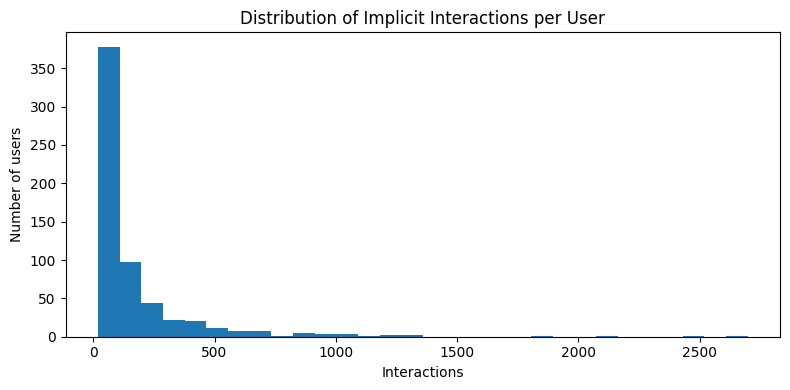

In [2]:
rng = np.random.default_rng(42)

user_ids = ratings['userId'].unique()
movie_ids = ratings['movieId'].unique()

user_to_idx = {user_id: idx for idx, user_id in enumerate(user_ids)}
movie_to_idx = {movie_id: idx for idx, movie_id in enumerate(movie_ids)}
idx_to_movie = {idx: movie_id for movie_id, idx in movie_to_idx.items()}

ratings = ratings.assign(
    user_idx=ratings['userId'].map(user_to_idx),
    movie_idx=ratings['movieId'].map(movie_to_idx),
    interaction=1,
)

# Leave one observed interaction out for testing on each user.
test_indices = []
for _, user_rows in ratings.groupby('user_idx'):
    test_indices.append(rng.choice(user_rows.index.to_numpy()))

test_mask = ratings.index.isin(test_indices)
train = ratings.loc[~test_mask].reset_index(drop=True)
test = ratings.loc[test_mask].reset_index(drop=True)

n_users = len(user_to_idx)
n_movies = len(movie_to_idx)

implicit_matrix = np.zeros((n_users, n_movies), dtype=np.uint8)
implicit_matrix[ratings['user_idx'].to_numpy(), ratings['movie_idx'].to_numpy()] = 1

train_matrix = np.zeros((n_users, n_movies), dtype=np.uint8)
train_matrix[train['user_idx'].to_numpy(), train['movie_idx'].to_numpy()] = 1

test_matrix = np.zeros((n_users, n_movies), dtype=np.uint8)
test_matrix[test['user_idx'].to_numpy(), test['movie_idx'].to_numpy()] = 1

print(f'users: {n_users:,}')
print(f'movies with ratings: {n_movies:,}')
print(f'train interactions: {len(train):,}')
print(f'test interactions: {len(test):,}')
print(f'implicit matrix shape: {implicit_matrix.shape}')
print(f'implicit density: {implicit_matrix.mean():.4%}')

interactions_per_user = ratings.groupby('user_idx').size()

plt.figure(figsize=(8, 4))
plt.hist(interactions_per_user, bins=30)
plt.title('Distribution of Implicit Interactions per User')
plt.xlabel('Interactions')
plt.ylabel('Number of users')
plt.tight_layout()
plt.show()

In [3]:
print(train.head())
print(test.head())

   userId  movieId  rating  timestamp  user_idx  movie_idx  interaction
0       1        1     4.0  964982703         0          0            1
1       1        3     4.0  964981247         0          1            1
2       1        6     4.0  964982224         0          2            1
3       1       47     5.0  964983815         0          3            1
4       1       50     5.0  964982931         0          4            1
   userId  movieId  rating   timestamp  user_idx  movie_idx  interaction
0       1      356     4.0   964980962         0         20            1
1       2   106782     5.0  1445714966         1        252            1
2       3     3949     0.5  1306464245         2        277            1
3       4     1304     3.0   945078467         3        360            1
4       5      316     2.0   847434832         4         17            1


## Train a simple matrix factorization model

For each user, BPR learns to score observed movies above unobserved movies.

`pairwise_probability = sigmoid(score(user, positive_movie) - score(user, negative_movie))`

The objective is binary cross entropy on that pairwise ranking probability with target `1`.

In [4]:
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -35, 35)))


def make_user_item_sets(frame):
    return frame.groupby('user_idx')['movie_idx'].apply(lambda values: set(values)).to_dict()


user_known_items = make_user_item_sets(ratings)


def sample_pairwise_preferences(train, user_known_items, n_movies, rng, pairs_per_positive=1):
    positives = train[['user_idx', 'movie_idx']].to_numpy(dtype=np.int64)
    positives = np.repeat(positives, pairs_per_positive, axis=0)

    triples = np.empty((len(positives), 3), dtype=np.int64)
    randomized_positions = rng.permutation(len(positives))

    for out_idx, positive_idx in enumerate(randomized_positions):
        user_idx, positive_movie_idx = positives[positive_idx]
        negative_movie_idx = rng.integers(n_movies)

        while negative_movie_idx in user_known_items[user_idx]:
            negative_movie_idx = rng.integers(n_movies)

        triples[out_idx] = (user_idx, positive_movie_idx, negative_movie_idx)

    return triples

In [5]:
def train_bpr(train, n_users, n_movies, k=32, epochs=10, lr=0.05, reg=0.002, pairs_per_positive=1, seed=42):
    rng = np.random.default_rng(seed)

    user_factors = rng.normal(0, 0.1, size=(n_users, k)).astype(np.float32)
    item_factors = rng.normal(0, 0.1, size=(n_movies, k)).astype(np.float32)
    item_bias = np.zeros(n_movies, dtype=np.float32)

    for epoch in range(epochs):
        total_loss = 0.0
        triples = sample_pairwise_preferences(
            train=train,
            user_known_items=user_known_items,
            n_movies=n_movies,
            rng=rng,
            pairs_per_positive=pairs_per_positive,
        )

        for user_idx, positive_movie_idx, negative_movie_idx in triples:
            user_embed = user_factors[user_idx].copy()
            positive_embed = item_factors[positive_movie_idx].copy()
            negative_embed = item_factors[negative_movie_idx].copy()

            score_difference = (
                item_bias[positive_movie_idx]
                - item_bias[negative_movie_idx]
                + np.dot(user_embed, positive_embed - negative_embed)
            )
            pairwise_probability = sigmoid(score_difference)
            total_loss += np.logaddexp(0, -score_difference)

            gradient = 1.0 - pairwise_probability

            item_bias[positive_movie_idx] += lr * (gradient - reg * item_bias[positive_movie_idx])
            item_bias[negative_movie_idx] += lr * (-gradient - reg * item_bias[negative_movie_idx])

            user_factors[user_idx] += lr * (gradient * (positive_embed - negative_embed) - reg * user_embed)
            item_factors[positive_movie_idx] += lr * (gradient * user_embed - reg * positive_embed)
            item_factors[negative_movie_idx] += lr * (-gradient * user_embed - reg * negative_embed)

        bce = total_loss / len(triples)
        print(f'epoch {epoch} pairwise BCE: {bce:.3f}')

    return user_factors, item_factors, item_bias

## Evaluate the model

Each user has exactly one held-out interaction. We rank that test movie against every movie the user did not see during training, then report leave-one-out ranking metrics.

In [6]:
def score_items(user_idx, movie_indices):
    return item_bias[movie_indices] + item_factors[movie_indices] @ user_factors[user_idx]


def evaluate_leave_one_out(test, train_matrix, k=10):
    hits = []
    ndcgs = []
    reciprocal_ranks = []

    for row in test.itertuples():
        user_idx = row.user_idx
        test_movie_idx = row.movie_idx

        candidate_movie_idx = np.flatnonzero(train_matrix[user_idx] == 0)
        scores = score_items(user_idx, candidate_movie_idx)
        rank = int(np.where(candidate_movie_idx[np.argsort(scores)[::-1]] == test_movie_idx)[0][0]) + 1

        hits.append(rank <= k)
        ndcgs.append(1 / np.log2(rank + 1) if rank <= k else 0.0)
        reciprocal_ranks.append(1 / rank)

    return {
        f'Hit Rate@{k}': np.mean(hits),
        f'NDCG@{k}': np.mean(ndcgs),
        'MRR': np.mean(reciprocal_ranks),
    }


user_factors, item_factors, item_bias = train_bpr(
    train,
    n_users,
    n_movies,
    k=32,
    epochs=10,
    lr=0.05,
    reg=0.002,
    pairs_per_positive=1,
    seed=42,
)

metrics = evaluate_leave_one_out(test, train_matrix, k=10)

for metric, value in metrics.items():
    print(f'{metric}: {value:.3f}')

epoch 0 pairwise BCE: 0.536
epoch 1 pairwise BCE: 0.403
epoch 2 pairwise BCE: 0.335
epoch 3 pairwise BCE: 0.279
epoch 4 pairwise BCE: 0.232
epoch 5 pairwise BCE: 0.199
epoch 6 pairwise BCE: 0.172
epoch 7 pairwise BCE: 0.153
epoch 8 pairwise BCE: 0.138
epoch 9 pairwise BCE: 0.125
Hit Rate@10: 0.113
NDCG@10: 0.066
MRR: 0.062


## Recommend movies for one user

For a selected user, score every unseen movie and return the top implicit-feedback recommendations.

In [7]:
movie_interaction_counts = ratings.groupby('movieId').size()


def show_user_likes(user_id, top_n=10):
    if user_id not in user_to_idx:
        raise ValueError(f'Unknown user_id: {user_id}')

    return (
        ratings.loc[ratings['userId'] == user_id, ['movieId', 'rating']]
        .merge(movies, on='movieId', how='left')
        .sort_values(['rating', 'title'], ascending=[False, True])
        .head(top_n)
        [['title', 'genres', 'rating']]
    )


def recommend_for_user(user_id, top_n=10, min_interactions=5):
    if user_id not in user_to_idx:
        raise ValueError(f'Unknown user_id: {user_id}')

    user_idx = user_to_idx[user_id]
    seen_movie_ids = set(ratings.loc[ratings['userId'] == user_id, 'movieId'])
    eligible_movie_ids = set(movie_interaction_counts[movie_interaction_counts >= min_interactions].index)

    candidate_movie_idx = np.array(
        [
            idx
            for idx, movie_id in idx_to_movie.items()
            if movie_id not in seen_movie_ids and movie_id in eligible_movie_ids
        ],
        dtype=np.int64,
    )
    if len(candidate_movie_idx) == 0:
        return pd.DataFrame(columns=['title', 'genres', 'predicted_score'])

    scores = score_items(user_idx, candidate_movie_idx)
    top_positions = np.argsort(scores)[-top_n:][::-1]
    top_movie_ids = [idx_to_movie[idx] for idx in candidate_movie_idx[top_positions]]

    return (
        pd.DataFrame({'movieId': top_movie_ids, 'predicted_score': scores[top_positions]})
        .merge(movies, on='movieId', how='left')
        [['title', 'genres', 'predicted_score']]
    )


user_id = 1

user_likes = show_user_likes(user_id=user_id, top_n=10)
recommendations = recommend_for_user(user_id=user_id, top_n=10)

print(f'User {user_id} highest-rated movies:')
display(user_likes)

print(f'Recommendations for user {user_id}:')
display(recommendations)

User 1 highest-rated movies:


,title,genres,rating
46,"Adventures of Robin Hood, The (1938)",Action|Adventure|Romance,5.0
56,Alice in Wonderland (1951),Adventure|Animation|Children|Fantasy|Musical,5.0
114,All Quiet on the Western Front (1930),Action|Drama|War,5.0
184,American Beauty (1999),Drama|Romance,5.0
147,American History X (1998),Crime|Drama,5.0
138,"American Tail, An (1986)",Adventure|Animation|Children|Comedy,5.0
98,Austin Powers: International Man of Mystery (1...,Action|Adventure|Comedy,5.0
85,Back to the Future (1985),Adventure|Comedy|Sci-Fi,5.0
120,Bambi (1942),Animation|Children|Drama,5.0
64,Basic Instinct (1992),Crime|Mystery|Thriller,5.0


Recommendations for user 1:


,title,genres,predicted_score
0,Speed (1994),Action|Romance|Thriller,5.949520
1,True Lies (1994),Action|Adventure|Comedy|Romance|Thriller,5.891706
2,Jerry Maguire (1996),Drama|Romance,5.855900
3,Cocoon (1985),Comedy|Sci-Fi,5.725810
4,"Hunt for Red October, The (1990)",Action|Adventure|Thriller,5.646697
5,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),Mystery|Sci-Fi|Thriller,5.568677
6,Aliens (1986),Action|Adventure|Horror|Sci-Fi,5.464746
7,Ferris Bueller's Day Off (1986),Comedy,5.411449
8,Shakespeare in Love (1998),Comedy|Drama|Romance,5.406511
9,Terminator 2: Judgment Day (1991),Action|Sci-Fi,5.399995
